# ML plots for alphas

## TR vs Te

### Trials

Index(['voltage', 'current', 'power', 'FR[%]', 'Q[W]', 'alpha', 'beta',
       'P[bar]', 'Te_mean[K]', 'Tc_mean[K]', 'Te_std[K]', 'Tc_std[K]',
       'T_pulse[K]', 'TR_train[K/W]'],
      dtype='object')


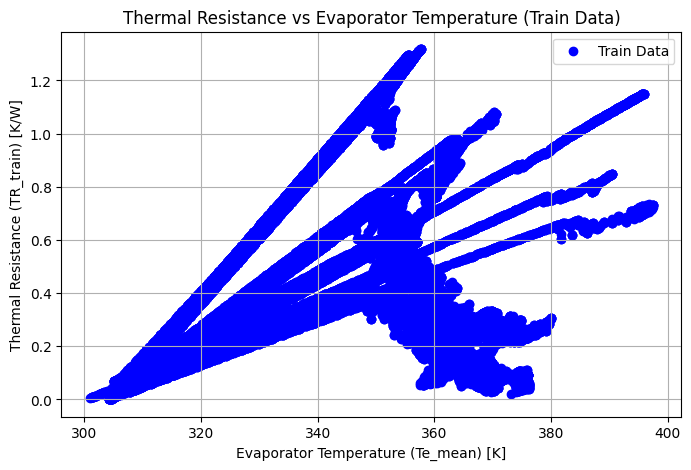

In [1]:
# Step 1: Plot TR_train [K/W] vs Te_mean [K] from x_y_train.csv

import pandas as pd
import matplotlib.pyplot as plt

# Load the training data
df_train = pd.read_csv('../ml_data/x_y_train.csv')

# Check the columns to ensure correct names
print(df_train.columns)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df_train['Te_mean[K]'], df_train['TR_train[K/W]'], color='blue', label='Train Data')
plt.xlabel('Evaporator Temperature (Te_mean) [K]')
plt.ylabel('Thermal Resistance (TR_train) [K/W]')
plt.title('Thermal Resistance vs Evaporator Temperature (Train Data)')
plt.legend()
plt.grid(True)
plt.show()

Train columns: Index(['voltage', 'current', 'power', 'FR[%]', 'Q[W]', 'alpha', 'beta',
       'P[bar]', 'Te_mean[K]', 'Tc_mean[K]', 'Te_std[K]', 'Tc_std[K]',
       'T_pulse[K]', 'TR_train[K/W]'],
      dtype='object')
Test columns: Index(['voltage', 'current', 'power', 'FR[%]', 'Q[W]', 'alpha', 'beta',
       'P[bar]', 'Te_mean[K]', 'Tc_mean[K]', 'Te_std[K]', 'Tc_std[K]',
       'T_pulse[K]', 'TR_test[K/W]', 'predictions_rfr', 'predictions_abr'],
      dtype='object')


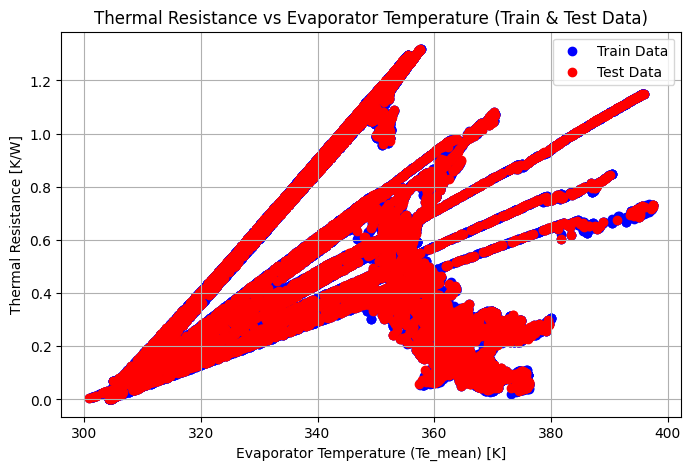

In [2]:
# Step 1: Plot TR_train [K/W] vs Te_mean [K] from x_y_train.csv
# Step 2: Plot TR_test [K/W] vs Te_mean [K] from x_y_test_predictions.csv

import pandas as pd
import matplotlib.pyplot as plt

# Load the training data
df_train = pd.read_csv('../ml_data/x_y_train.csv')

# Load the test data
df_test = pd.read_csv('../ml_data/x_y_test_predictions.csv')

# Check the columns to ensure correct names
print("Train columns:", df_train.columns)
print("Test columns:", df_test.columns)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df_train['Te_mean[K]'], df_train['TR_train[K/W]'], color='blue', label='Train Data')
plt.scatter(df_test['Te_mean[K]'], df_test['TR_test[K/W]'], color='red', label='Test Data')
plt.xlabel('Evaporator Temperature (Te_mean) [K]')
plt.ylabel('Thermal Resistance [K/W]')
plt.title('Thermal Resistance vs Evaporator Temperature (Train & Test Data)')
plt.legend()
plt.grid(True)
plt.show()

Train columns: Index(['voltage', 'current', 'power', 'FR[%]', 'Q[W]', 'alpha', 'beta',
       'P[bar]', 'Te_mean[K]', 'Tc_mean[K]', 'Te_std[K]', 'Tc_std[K]',
       'T_pulse[K]', 'TR_train[K/W]'],
      dtype='object')
Test columns: Index(['voltage', 'current', 'power', 'FR[%]', 'Q[W]', 'alpha', 'beta',
       'P[bar]', 'Te_mean[K]', 'Tc_mean[K]', 'Te_std[K]', 'Tc_std[K]',
       'T_pulse[K]', 'TR_test[K/W]', 'TR_predictions_rfr[K/W]',
       'TR_predictions_abr[K/W]'],
      dtype='object')


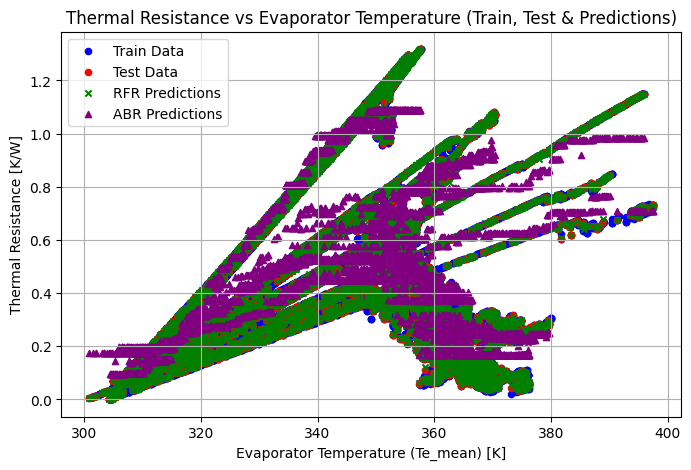

In [8]:
# Step 1: Plot TR_train [K/W] vs Te_mean [K] from x_y_train.csv
# Step 2: Plot TR_test [K/W] vs Te_mean [K] from x_y_test_predictions.csv
# Step 3: Plot TR_predictions_rfr [K/W] vs Te_mean [K] and TR_predictions_abr [K/W] vs Te_mean [K] from x_y_test_predictions.csv

import pandas as pd
import matplotlib.pyplot as plt

# Load the training data
df_train = pd.read_csv('../ml_data/x_y_train.csv')

# Load the test and predictions data
df_test = pd.read_csv('../ml_data/x_y_test_predictions.csv')

# Check the columns to ensure correct names
print("Train columns:", df_train.columns)
print("Test columns:", df_test.columns)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df_train['Te_mean[K]'], df_train['TR_train[K/W]'], color='blue', label='Train Data', s=20)
plt.scatter(df_test['Te_mean[K]'], df_test['TR_test[K/W]'], color='red', label='Test Data', s=20)
plt.scatter(df_test['Te_mean[K]'], df_test['TR_predictions_rfr[K/W]'], color='green', label='RFR Predictions', s=20, marker='x')
plt.scatter(df_test['Te_mean[K]'], df_test['TR_predictions_abr[K/W]'], color='purple', label='ABR Predictions', s=20, marker='^')
plt.xlabel('Evaporator Temperature (Te_mean) [K]')
plt.ylabel('Thermal Resistance [K/W]')
plt.title('Thermal Resistance vs Evaporator Temperature (Train, Test & Predictions)')
plt.legend()
plt.grid(True)
plt.show()

### Trials - TR vs Te - sub plots

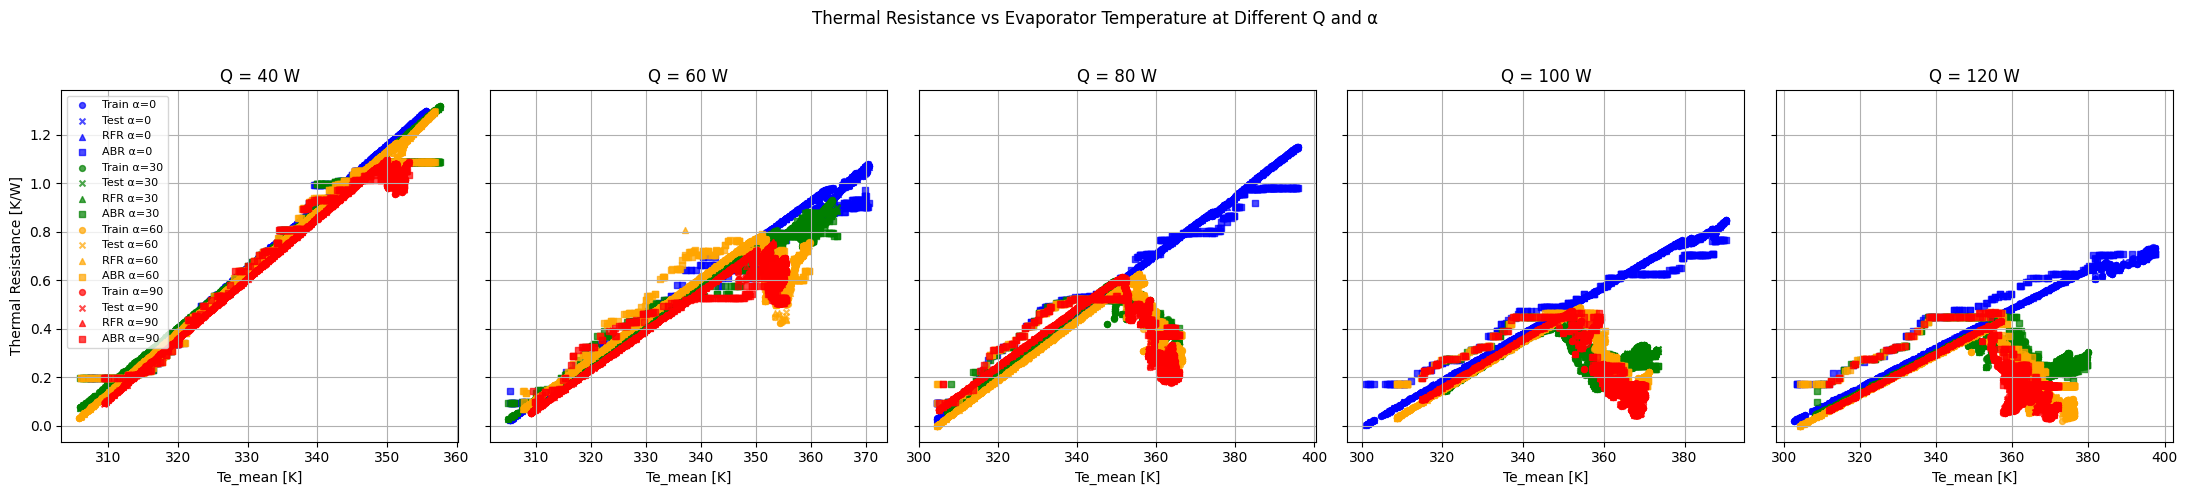

In [9]:
# Subplots of TR vs Te_mean for each Q, colored by alpha
import pandas as pd
import matplotlib.pyplot as plt

# Load the training data
df_train = pd.read_csv('../ml_data/x_y_train.csv')
# Load the test and predictions data
df_test = pd.read_csv('../ml_data/x_y_test_predictions.csv')

# Ensure Q[W] and alpha columns exist and are numeric
df_train['Q[W]'] = pd.to_numeric(df_train['Q[W]'], errors='coerce')
df_train['alpha'] = pd.to_numeric(df_train['alpha'], errors='coerce')
df_test['Q[W]'] = pd.to_numeric(df_test['Q[W]'], errors='coerce')
df_test['alpha'] = pd.to_numeric(df_test['alpha'], errors='coerce')

Q_values = [40, 60, 80, 100, 120]
alpha_values = [0, 30, 60, 90]
alpha_colors = {0: 'blue', 30: 'green', 60: 'orange', 90: 'red'}

fig, axes = plt.subplots(1, len(Q_values), figsize=(22, 5), sharey=True)
for idx, Q in enumerate(Q_values):
    ax = axes[idx]
    for alpha in alpha_values:
        # Train data
        mask_train = (df_train['Q[W]'] == Q) & (df_train['alpha'] == alpha)
        ax.scatter(
            df_train.loc[mask_train, 'Te_mean[K]'],
            df_train.loc[mask_train, 'TR_train[K/W]'],
            color=alpha_colors[alpha], s=18, label=f'Train α={alpha}' if idx == 0 else "", marker='o', alpha=0.7
        )
        # Test data
        mask_test = (df_test['Q[W]'] == Q) & (df_test['alpha'] == alpha)
        ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_test[K/W]'],
            color=alpha_colors[alpha], s=18, label=f'Test α={alpha}' if idx == 0 else "", marker='x', alpha=0.7
        )
        # RFR predictions
        ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_predictions_rfr[K/W]'],
            color=alpha_colors[alpha], s=18, label=f'RFR α={alpha}' if idx == 0 else "", marker='^', alpha=0.7
        )
        # ABR predictions
        ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_predictions_abr[K/W]'],
            color=alpha_colors[alpha], s=18, label=f'ABR α={alpha}' if idx == 0 else "", marker='s', alpha=0.7
        )
    ax.set_title(f'Q = {Q} W')
    ax.set_xlabel('Te_mean [K]')
    if idx == 0:
        ax.set_ylabel('Thermal Resistance [K/W]')
    ax.grid(True)
    if idx == 0:
        ax.legend(fontsize=8, loc='best', frameon=True)

plt.suptitle('Thermal Resistance vs Evaporator Temperature at Different Q and α')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

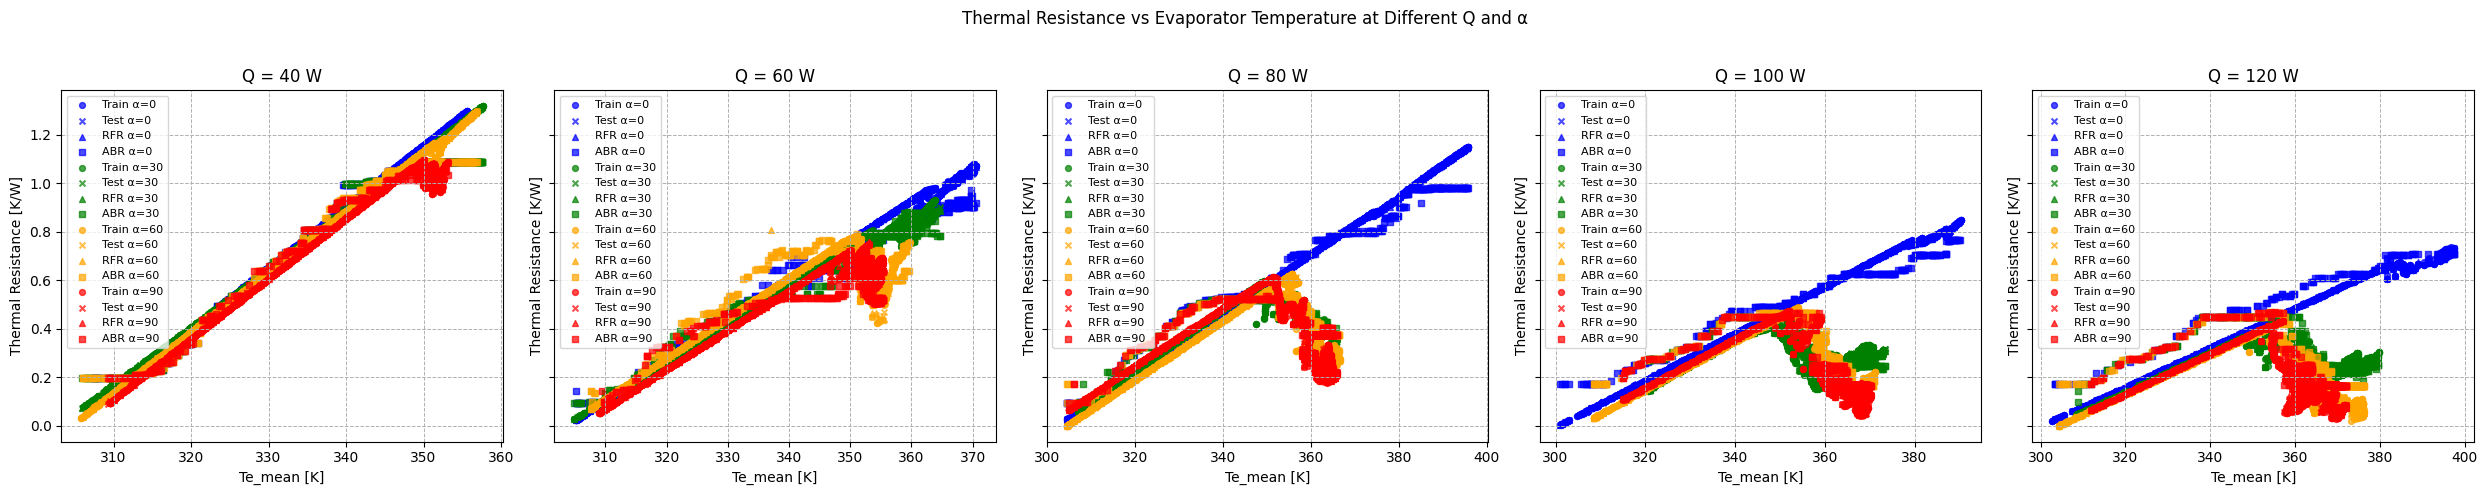

In [14]:
# Subplots of TR vs Te_mean for each Q, colored by alpha, with individual legends and improved grid
import pandas as pd
import matplotlib.pyplot as plt

# Load the training data
df_train = pd.read_csv('../ml_data/x_y_train.csv')
# Load the test and predictions data
df_test = pd.read_csv('../ml_data/x_y_test_predictions.csv')

# Ensure Q[W] and alpha columns exist and are numeric
df_train['Q[W]'] = pd.to_numeric(df_train['Q[W]'], errors='coerce')
df_train['alpha'] = pd.to_numeric(df_train['alpha'], errors='coerce')
df_test['Q[W]'] = pd.to_numeric(df_test['Q[W]'], errors='coerce')
df_test['alpha'] = pd.to_numeric(df_test['alpha'], errors='coerce')

Q_values = [40, 60, 80, 100, 120]
alpha_values = [0, 30, 60, 90]
alpha_colors = {0: 'blue', 30: 'green', 60: 'orange', 90: 'red'}

fig, axes = plt.subplots(1, len(Q_values), figsize=(25, 5), sharey=True)
for idx, Q in enumerate(Q_values):
    ax = axes[idx]
    handles = []
    labels = []
    for alpha in alpha_values:
        # Train data
        mask_train = (df_train['Q[W]'] == Q) & (df_train['alpha'] == alpha)
        h1 = ax.scatter(
            df_train.loc[mask_train, 'Te_mean[K]'],
            df_train.loc[mask_train, 'TR_train[K/W]'],
            color=alpha_colors[alpha], s=18, marker='o', alpha=0.7,
            label=f'Train α={alpha}'
        )
        # Test data
        mask_test = (df_test['Q[W]'] == Q) & (df_test['alpha'] == alpha)
        h2 = ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_test[K/W]'],
            color=alpha_colors[alpha], s=18, marker='x', alpha=0.7,
            label=f'Test α={alpha}'
        )
        # RFR predictions
        h3 = ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_predictions_rfr[K/W]'],
            color=alpha_colors[alpha], s=18, marker='^', alpha=0.7,
            label=f'RFR α={alpha}'
        )
        # ABR predictions
        h4 = ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_predictions_abr[K/W]'],
            color=alpha_colors[alpha], s=18, marker='s', alpha=0.7,
            label=f'ABR α={alpha}'
        )
        # Add only if data exists for legend
        for h, l in zip([h1, h2, h3, h4], [f'Train α={alpha}', f'Test α={alpha}', f'RFR α={alpha}', f'ABR α={alpha}']):
            if h.get_offsets().size > 0:
                handles.append(h)
                labels.append(l)
    ax.set_title(f'Q = {Q} W')
    ax.set_xlabel('Te_mean [K]')
    ax.set_ylabel('Thermal Resistance [K/W]')
    ax.grid(True, linestyle='--', linewidth=0.7)
    # Show legend for each subplot
    ax.legend(handles, labels, fontsize=8, loc='best', frameon=True)

plt.suptitle('Thermal Resistance vs Evaporator Temperature at Different Q and α')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

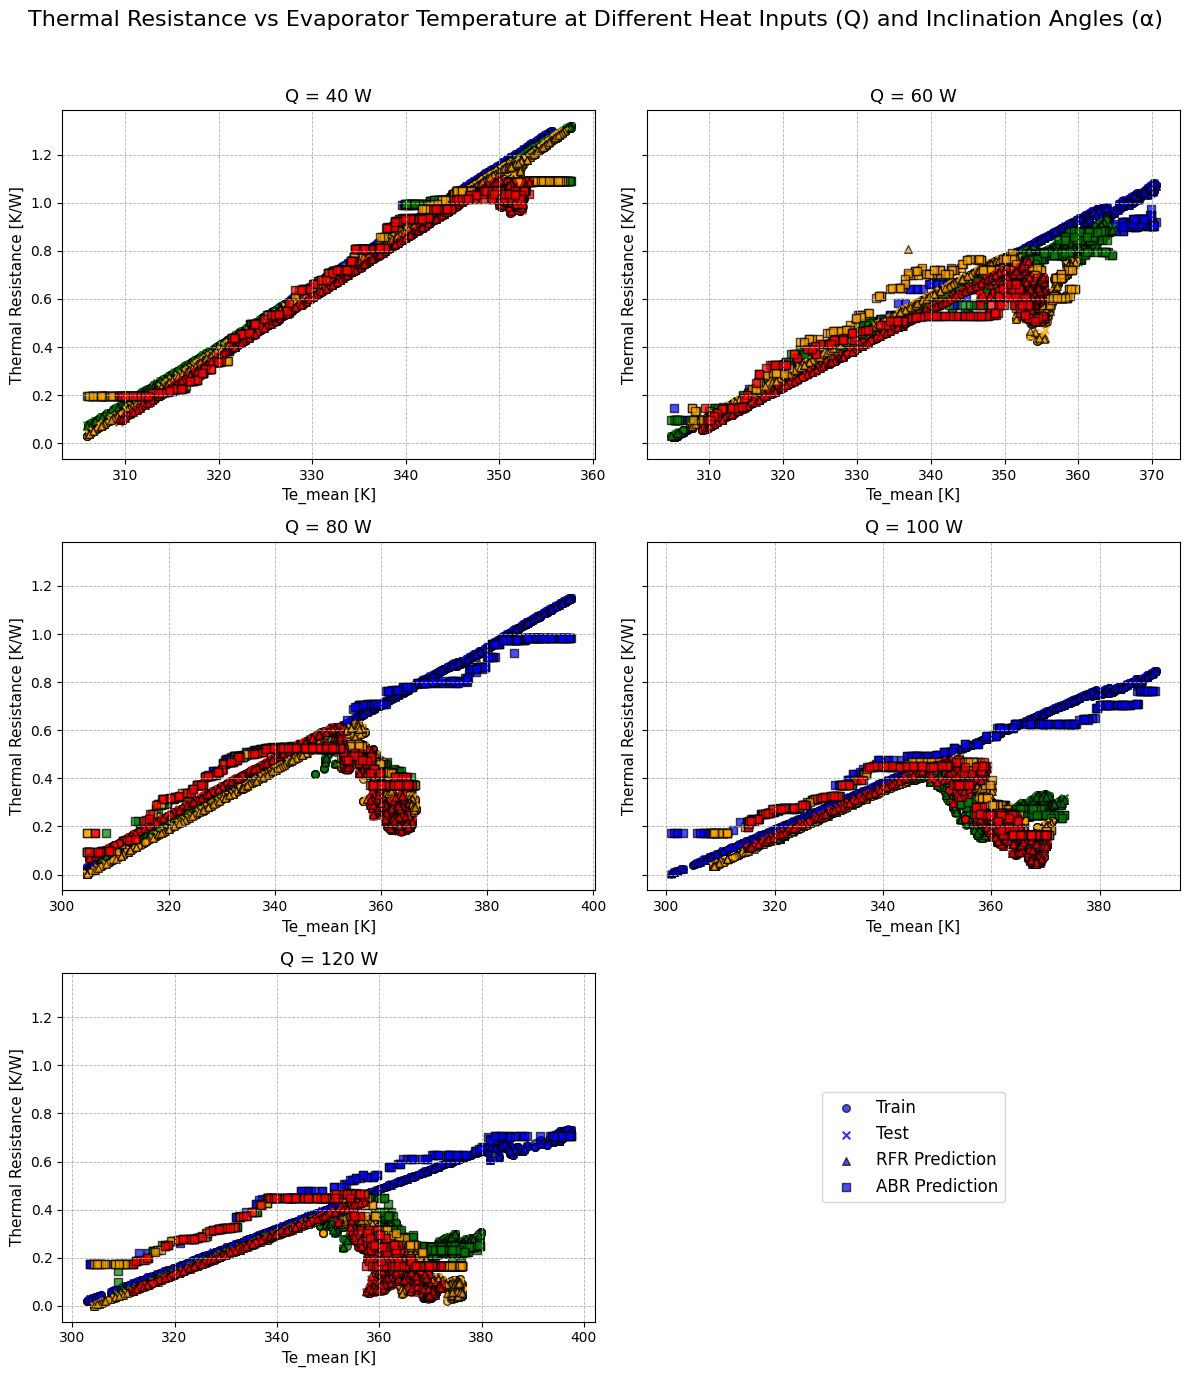

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Step 1: Load Data
# -----------------------------------------------------------
df_train = pd.read_csv('../ml_data/x_y_train.csv')
df_test = pd.read_csv('../ml_data/x_y_test_predictions.csv')

# -----------------------------------------------------------
# Step 2: Ensure numeric columns
# -----------------------------------------------------------
df_train['Q[W]'] = pd.to_numeric(df_train['Q[W]'], errors='coerce')
df_train['alpha'] = pd.to_numeric(df_train['alpha'], errors='coerce')

df_test['Q[W]'] = pd.to_numeric(df_test['Q[W]'], errors='coerce')
df_test['alpha'] = pd.to_numeric(df_test['alpha'], errors='coerce')

# -----------------------------------------------------------
# Step 3: Define parameters
# -----------------------------------------------------------
Q_values = [40, 60, 80, 100, 120]
alpha_values = [0, 30, 60, 90]

alpha_colors = {
    0: 'blue',
    30: 'green',
    60: 'orange',
    90: 'red'
}

# -----------------------------------------------------------
# Step 4: Create 3x2 subplot layout
# -----------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(12, 14), sharey=True)
axes = axes.flatten()

# -----------------------------------------------------------
# Step 5: Legend storage
# -----------------------------------------------------------
legend_handles = []
legend_labels = []

# -----------------------------------------------------------
# Step 6: Loop over Q values
# -----------------------------------------------------------
for idx, Q in enumerate(Q_values):

    ax = axes[idx]

    for alpha in alpha_values:

        # ---------------- Train ----------------
        mask_train = (df_train['Q[W]'] == Q) & (df_train['alpha'] == alpha)

        h1 = ax.scatter(
            df_train.loc[mask_train, 'Te_mean[K]'],
            df_train.loc[mask_train, 'TR_train[K/W]'],
            color=alpha_colors[alpha],
            marker='o',
            s=30,
            edgecolors='black',
            alpha=0.7
        )

        # ---------------- Test ----------------
        mask_test = (df_test['Q[W]'] == Q) & (df_test['alpha'] == alpha)

        h2 = ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_test[K/W]'],
            color=alpha_colors[alpha],
            marker='x',
            s=30,
            alpha=0.8
        )

        # ---------------- RFR ----------------
        h3 = ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_predictions_rfr[K/W]'],
            color=alpha_colors[alpha],
            marker='^',
            s=30,
            edgecolors='black',
            alpha=0.7
        )

        # ---------------- ABR ----------------
        h4 = ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_predictions_abr[K/W]'],
            color=alpha_colors[alpha],
            marker='s',
            s=30,
            edgecolors='black',
            alpha=0.7
        )

        # Collect legend ONLY once
        if idx == 0 and alpha == 0:
            legend_handles = [h1, h2, h3, h4]
            legend_labels = [
                'Train',
                'Test',
                'RFR Prediction',
                'ABR Prediction'
            ]

    # ---------------- Subplot formatting ----------------
    ax.set_title(f'Q = {Q} W', fontsize=13)
    ax.set_xlabel('Te_mean [K]', fontsize=11)
    ax.set_ylabel('Thermal Resistance [K/W]', fontsize=11)
    ax.grid(True, linestyle='--', linewidth=0.6)

# -----------------------------------------------------------
# Step 7: Use last subplot ONLY for legend
# -----------------------------------------------------------
legend_ax = axes[-1]
legend_ax.axis('off')  # remove axes

legend_ax.legend(
    legend_handles,
    legend_labels,
    loc='center',
    fontsize=12,
    frameon=True
)

# -----------------------------------------------------------
# Step 8: Global Title
# -----------------------------------------------------------
plt.suptitle(
    'Thermal Resistance vs Evaporator Temperature at Different Heat Inputs (Q) and Inclination Angles (α)',
    fontsize=16
)

# -----------------------------------------------------------
# Step 9: Layout adjustment
# -----------------------------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.96])

# -----------------------------------------------------------
# Step 10: Show plot
# -----------------------------------------------------------
plt.show()

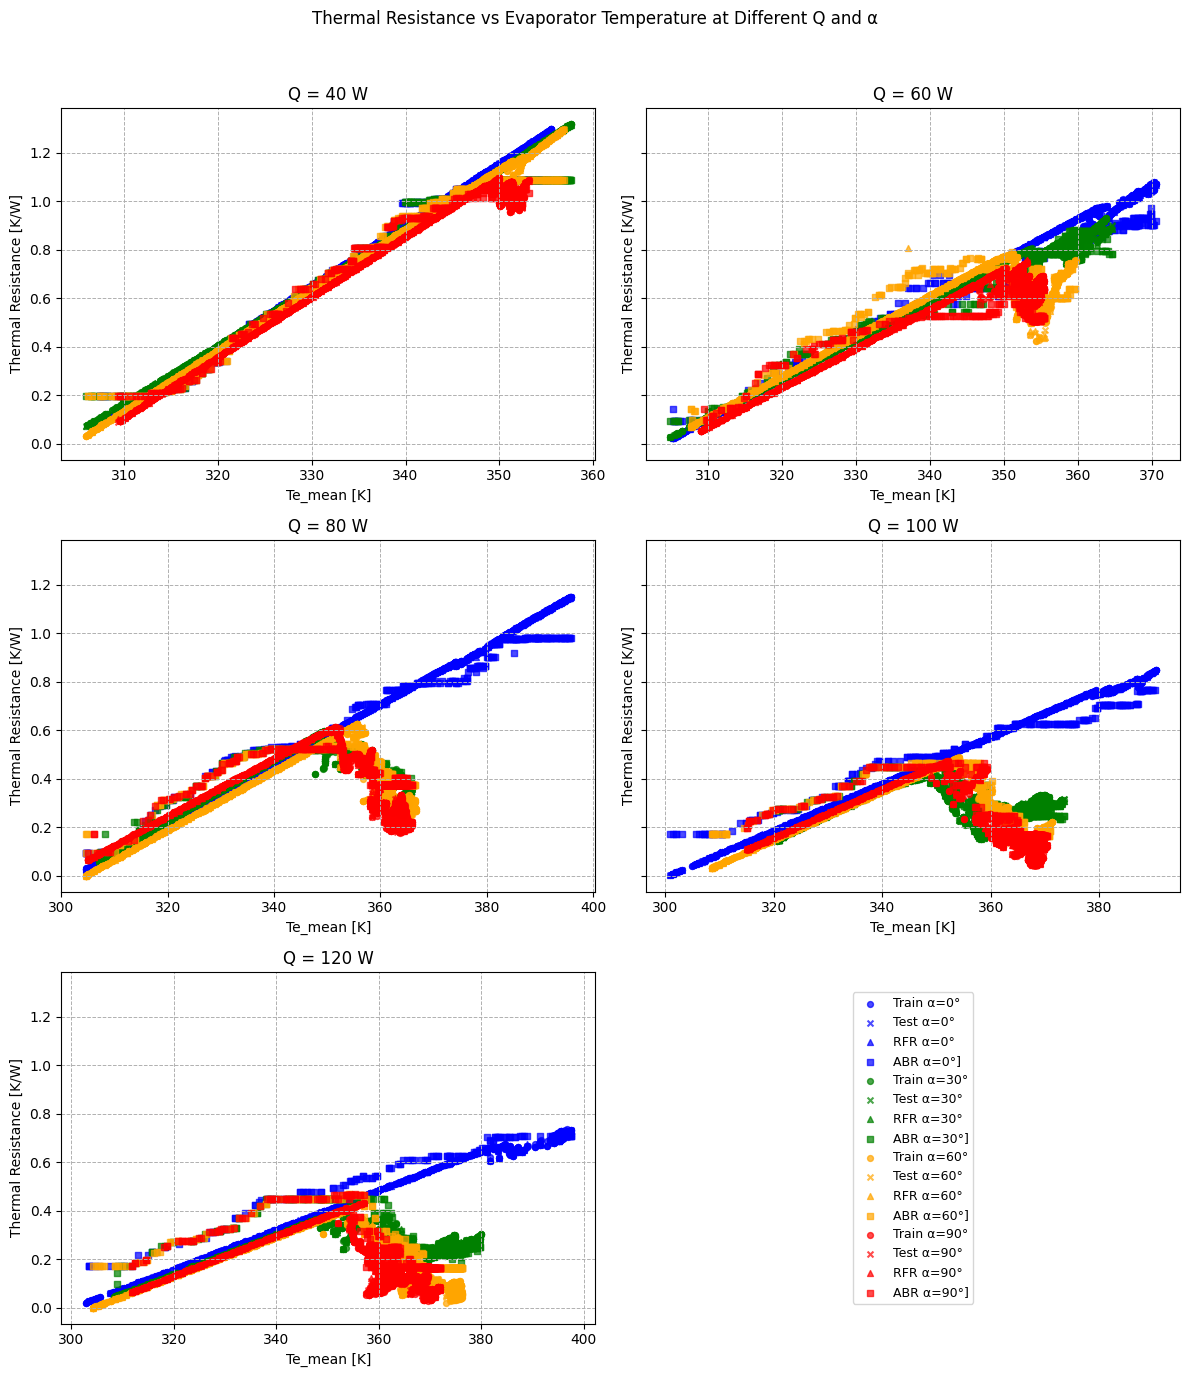

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the training data
df_train = pd.read_csv('../ml_data/x_y_train.csv')
# Load the test and predictions data
df_test = pd.read_csv('../ml_data/x_y_test_predictions.csv')

# Ensure Q[W] and alpha columns exist and are numeric
df_train['Q[W]'] = pd.to_numeric(df_train['Q[W]'], errors='coerce')
df_train['alpha'] = pd.to_numeric(df_train['alpha'], errors='coerce')
df_test['Q[W]'] = pd.to_numeric(df_test['Q[W]'], errors='coerce')
df_test['alpha'] = pd.to_numeric(df_test['alpha'], errors='coerce')

Q_values = [40, 60, 80, 100, 120]
alpha_values = [0, 30, 60, 90]
alpha_colors = {0: 'blue', 30: 'green', 60: 'orange', 90: 'red'}

# ------------------ CHANGED: 3x2 layout ------------------
fig, axes = plt.subplots(3, 2, figsize=(12, 14), sharey=True)
axes = axes.flatten()

for idx, Q in enumerate(Q_values):
    ax = axes[idx]
    handles = []
    labels = []

    for alpha in alpha_values:
        # Train data
        mask_train = (df_train['Q[W]'] == Q) & (df_train['alpha'] == alpha)
        h1 = ax.scatter(
            df_train.loc[mask_train, 'Te_mean[K]'],
            df_train.loc[mask_train, 'TR_train[K/W]'],
            color=alpha_colors[alpha], s=18, marker='o', alpha=0.7,
            label=f'Train α={alpha}°'
        )

        # Test data
        mask_test = (df_test['Q[W]'] == Q) & (df_test['alpha'] == alpha)
        h2 = ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_test[K/W]'],
            color=alpha_colors[alpha], s=18, marker='x', alpha=0.7,
            label=f'Test α={alpha}°'
        )

        # RFR predictions
        h3 = ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_predictions_rfr[K/W]'],
            color=alpha_colors[alpha], s=18, marker='^', alpha=0.7,
            label=f'RFR α={alpha}°'
        )

        # ABR predictions
        h4 = ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_predictions_abr[K/W]'],
            color=alpha_colors[alpha], s=18, marker='s', alpha=0.7,
            label=f'ABR α={alpha}°'
        )

        # Add only if data exists for legend
        for h, l in zip(
            [h1, h2, h3, h4],
            [f'Train α={alpha}°', f'Test α={alpha}°', f'RFR α={alpha}°', f'ABR α={alpha}°]']
        ):
            if h.get_offsets().size > 0:
                handles.append(h)
                labels.append(l)

    ax.set_title(f'Q = {Q} W')
    ax.set_xlabel('Te_mean [K]')
    ax.set_ylabel('Thermal Resistance [K/W]')
    ax.grid(True, linestyle='--', linewidth=0.7)

    # ------------------ CHANGED: legend only for first subplot ------------------
    if idx == 0:
        legend_handles = handles
        legend_labels = labels

# ------------------ CHANGED: use last subplot for legend ------------------
legend_ax = axes[-1]
legend_ax.axis('off')

legend_ax.legend(
    legend_handles,
    legend_labels,
    fontsize=9,
    loc='center',
    frameon=True
)

plt.suptitle('Thermal Resistance vs Evaporator Temperature at Different Q and α')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Final sub plot

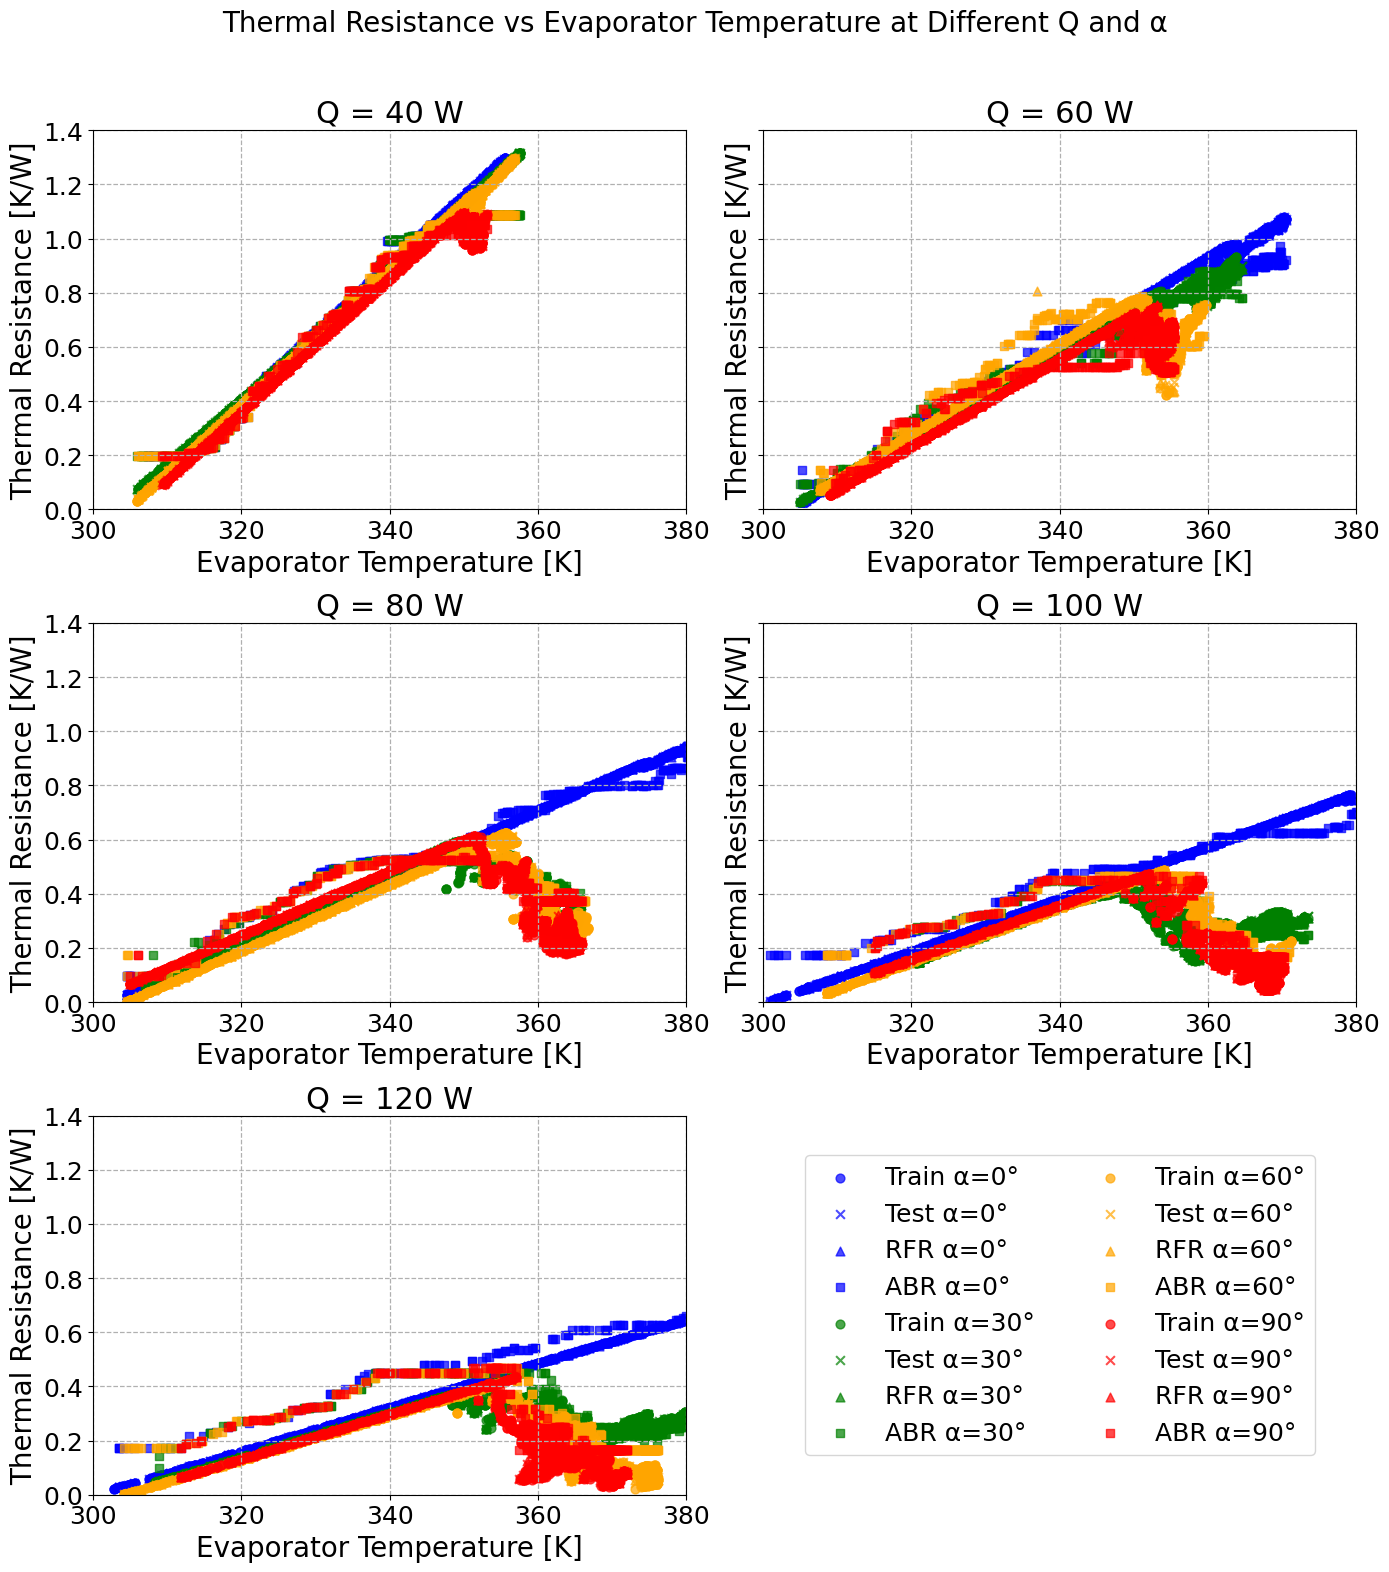

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the training data
df_train = pd.read_csv('../ml_data/x_y_train.csv')
# Load the test and predictions data
df_test = pd.read_csv('../ml_data/x_y_test_predictions.csv')

# Ensure Q[W] and alpha columns exist and are numeric
df_train['Q[W]'] = pd.to_numeric(df_train['Q[W]'], errors='coerce')
df_train['alpha'] = pd.to_numeric(df_train['alpha'], errors='coerce')
df_test['Q[W]'] = pd.to_numeric(df_test['Q[W]'], errors='coerce')
df_test['alpha'] = pd.to_numeric(df_test['alpha'], errors='coerce')

Q_values = [40, 60, 80, 100, 120]
alpha_values = [0, 30, 60, 90]
alpha_colors = {0: 'blue', 30: 'green', 60: 'orange', 90: 'red'}

# Set global font sizes for publication
plt.rcParams.update({
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'figure.titlesize': 24
})

fig, axes = plt.subplots(3, 2, figsize=(14, 16), sharey=True)
axes = axes.flatten()

for idx, Q in enumerate(Q_values):
    ax = axes[idx]
    handles = []
    labels = []

    for alpha in alpha_values:
        # Train data
        mask_train = (df_train['Q[W]'] == Q) & (df_train['alpha'] == alpha)
        h1 = ax.scatter(
            df_train.loc[mask_train, 'Te_mean[K]'],
            df_train.loc[mask_train, 'TR_train[K/W]'],
            color=alpha_colors[alpha], s=40, marker='o', alpha=0.7,
            label=f'Train α={alpha}°'
        )

        # Test data
        mask_test = (df_test['Q[W]'] == Q) & (df_test['alpha'] == alpha)
        h2 = ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_test[K/W]'],
            color=alpha_colors[alpha], s=40, marker='x', alpha=0.7,
            label=f'Test α={alpha}°'
        )

        # RFR predictions
        h3 = ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_predictions_rfr[K/W]'],
            color=alpha_colors[alpha], s=40, marker='^', alpha=0.7,
            label=f'RFR α={alpha}°'
        )

        # ABR predictions
        h4 = ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_predictions_abr[K/W]'],
            color=alpha_colors[alpha], s=40, marker='s', alpha=0.7,
            label=f'ABR α={alpha}°'
        )

        # Add only if data exists for legend
        for h, l in zip(
            [h1, h2, h3, h4],
            [f'Train α={alpha}°', f'Test α={alpha}°', f'RFR α={alpha}°', f'ABR α={alpha}°']
        ):
            if h.get_offsets().size > 0:
                handles.append(h)
                labels.append(l)

    ax.set_title(f'Q = {Q} W', fontsize=22)
    ax.set_xlabel('Evaporator Temperature [K]', fontsize=20)
    ax.set_ylabel('Thermal Resistance [K/W]', fontsize=20)
    ax.grid(True, linestyle='--', linewidth=0.9)
    ax.set_xlim(300, 380)
    ax.set_ylim(0, 1.4)
    ax.tick_params(axis='both', which='major', labelsize=18)

    # Legend only for first subplot
    if idx == 0:
        legend_handles = handles
        legend_labels = labels

# Use last subplot for legend
legend_ax = axes[-1]
legend_ax.axis('off')

legend_ax.legend(
    legend_handles,
    legend_labels,
    fontsize=18,
    loc='center',
    frameon=True,
    ncol=2,             # to arrange legend in 2 columns
    columnspacing=2,
    handletextpad=0.8
)

plt.suptitle('Thermal Resistance vs Evaporator Temperature at Different Q and α', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 1

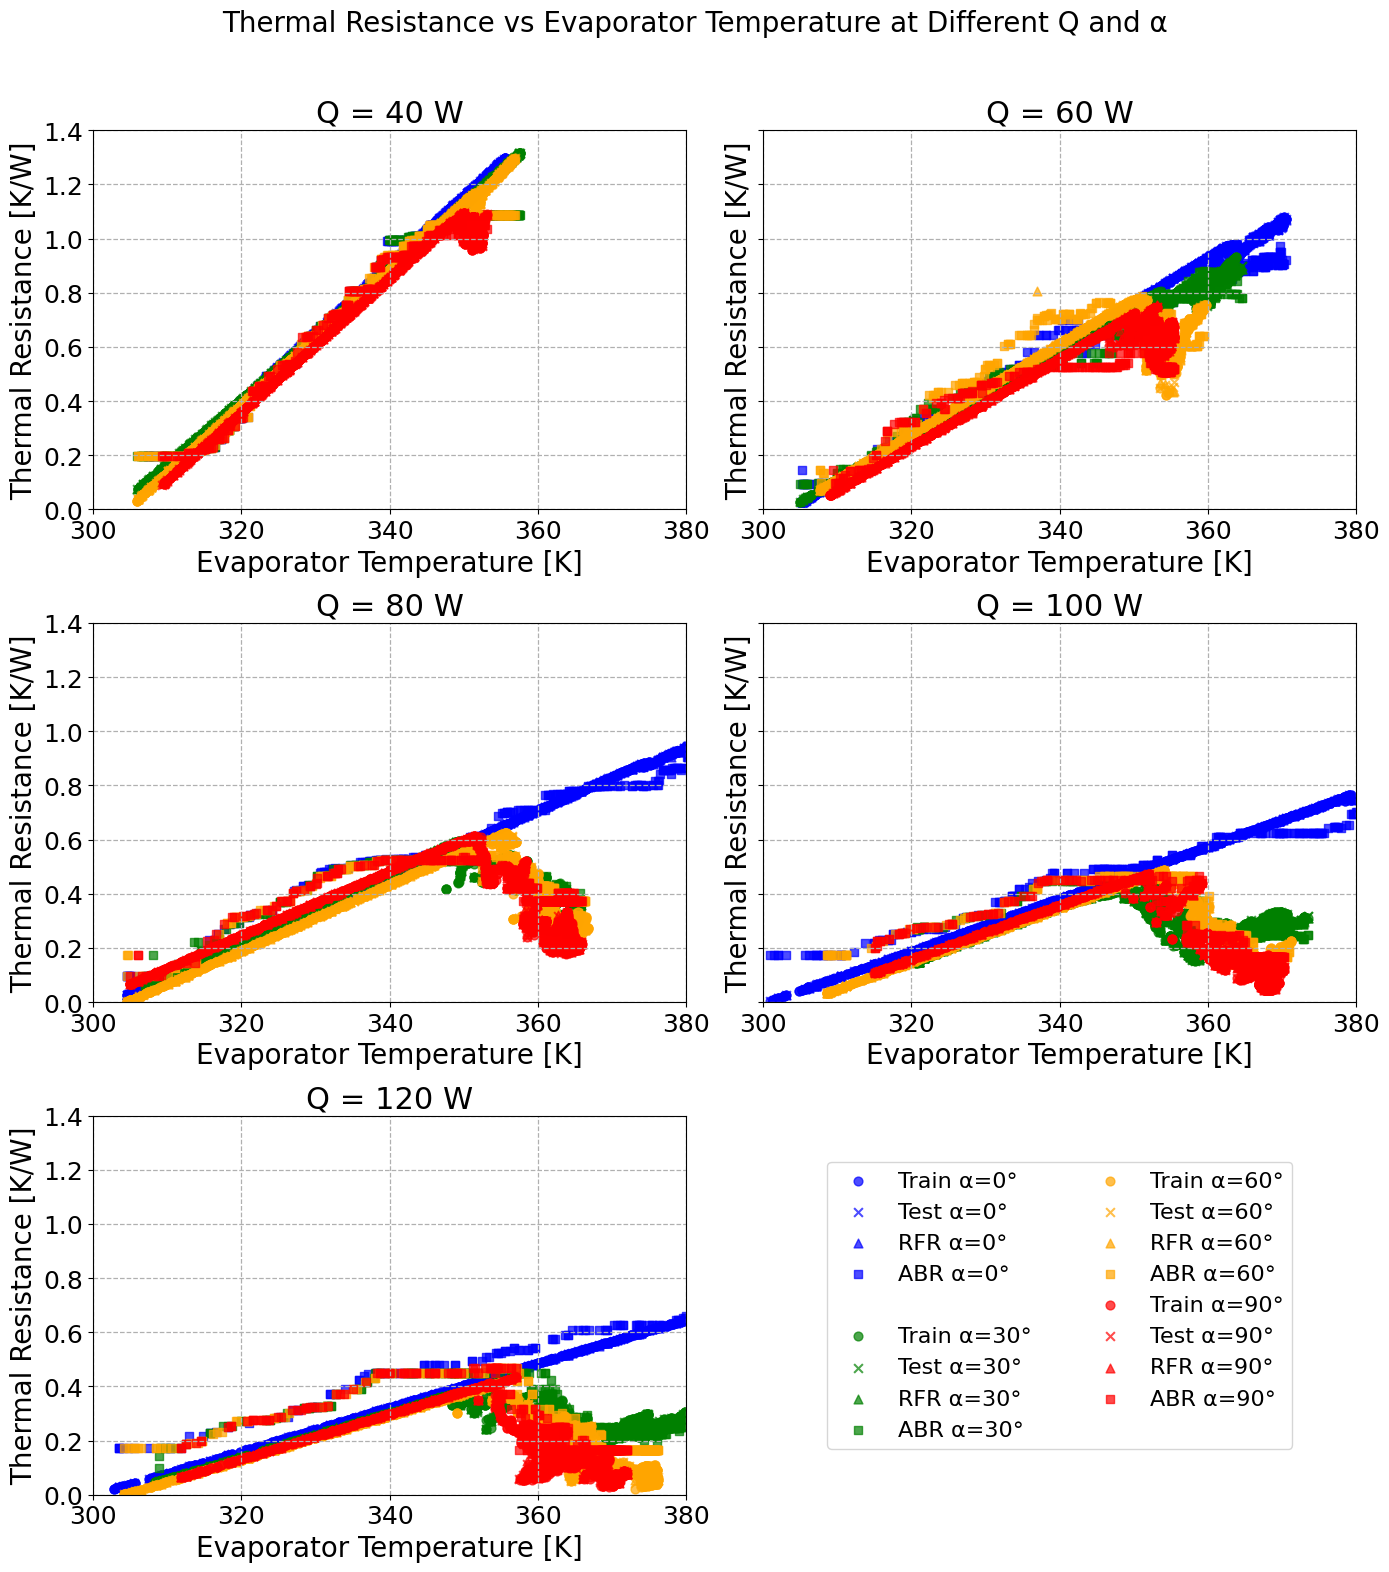

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Load the training data
df_train = pd.read_csv('../ml_data/x_y_train.csv')
# Load the test and predictions data
df_test = pd.read_csv('../ml_data/x_y_test_predictions.csv')

# Ensure Q[W] and alpha columns exist and are numeric
df_train['Q[W]'] = pd.to_numeric(df_train['Q[W]'], errors='coerce')
df_train['alpha'] = pd.to_numeric(df_train['alpha'], errors='coerce')
df_test['Q[W]'] = pd.to_numeric(df_test['Q[W]'], errors='coerce')
df_test['alpha'] = pd.to_numeric(df_test['alpha'], errors='coerce')

Q_values = [40, 60, 80, 100, 120]
alpha_values = [0, 30, 60, 90]
alpha_colors = {0: 'blue', 30: 'green', 60: 'orange', 90: 'red'}

# Set global font sizes for publication
plt.rcParams.update({
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'figure.titlesize': 24
})

fig, axes = plt.subplots(3, 2, figsize=(14, 16), sharey=True)
axes = axes.flatten()

for idx, Q in enumerate(Q_values):
    ax = axes[idx]
    handles = []
    labels = []

    for alpha in alpha_values:
        # Train data
        mask_train = (df_train['Q[W]'] == Q) & (df_train['alpha'] == alpha)
        h1 = ax.scatter(
            df_train.loc[mask_train, 'Te_mean[K]'],
            df_train.loc[mask_train, 'TR_train[K/W]'],
            color=alpha_colors[alpha], s=40, marker='o', alpha=0.7,
            label=f'Train α={alpha}°'
        )

        # Test data
        mask_test = (df_test['Q[W]'] == Q) & (df_test['alpha'] == alpha)
        h2 = ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_test[K/W]'],
            color=alpha_colors[alpha], s=40, marker='x', alpha=0.7,
            label=f'Test α={alpha}°'
        )

        # RFR predictions
        h3 = ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_predictions_rfr[K/W]'],
            color=alpha_colors[alpha], s=40, marker='^', alpha=0.7,
            label=f'RFR α={alpha}°'
        )

        # ABR predictions
        h4 = ax.scatter(
            df_test.loc[mask_test, 'Te_mean[K]'],
            df_test.loc[mask_test, 'TR_predictions_abr[K/W]'],
            color=alpha_colors[alpha], s=40, marker='s', alpha=0.7,
            label=f'ABR α={alpha}°'
        )

        # Add only if data exists for legend
        for h, l in zip(
            [h1, h2, h3, h4],
            [f'Train α={alpha}°', f'Test α={alpha}°', f'RFR α={alpha}°', f'ABR α={alpha}°']
        ):
            if h.get_offsets().size > 0:
                handles.append(h)
                labels.append(l)

    ax.set_title(f'Q = {Q} W', fontsize=22)
    ax.set_xlabel('Evaporator Temperature [K]', fontsize=20)
    ax.set_ylabel('Thermal Resistance [K/W]', fontsize=20)
    ax.grid(True, linestyle='--', linewidth=0.9)
    ax.set_xlim(300, 380)
    ax.set_ylim(0, 1.4)
    ax.tick_params(axis='both', which='major', labelsize=18)

    # Legend only for first subplot
    if idx == 0:
        legend_handles = handles
        legend_labels = labels


# After collecting legend_handles and legend_labels (should be 8 items: 4 for α=0/30, 4 for α=60/90)
blank = Line2D([], [], linestyle="none")
legend_handles.insert(4, blank)
legend_labels.insert(4, '')  # Add a blank entry for separation in legend   


# Use last subplot for legend
legend_ax = axes[-1]
legend_ax.axis('off')

# Now create the legend
legend_ax.legend(
    legend_handles,
    legend_labels,
    fontsize=16,
    loc='center',
    frameon=True,
    ncol=2,             # to arrange legend in 2 columns
    columnspacing=2.5,
    handletextpad=0.8
)

plt.suptitle('Thermal Resistance vs Evaporator Temperature at Different Q and α', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()